In [2]:
# import necessary libraries
import sqlite3 # for connecting python to a database
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Establish the connection to the database
conn = sqlite3.connect('../data/Chinook_Sqlite.sqlite')

Reading the SQL file to get list of tables in database

In [4]:
# Verification query to check the connection and list tables in the database, that means reading the SQL file

with open('../queries/verify_connection.sql', 'r') as file:
    query = file.read()

print(query, "\n")

# Execute the query and fetch results
table = pd.read_sql_query(query, conn)
print(table)

SELECT name
FROM sqlite_master
WHERE type='table'; 

             name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track


Now checking what each table actually contains

In [5]:
import run_sql as rs

query_files = [
    'Album_schema.sql',
    'Artist_schema.sql',
    'Customer_schema.sql',
    'Employee_schema.sql',
    'Genre_schema.sql',
    'Invoice_schema.sql',
    'InvoiceLine_schema.sql',
    'MediaType_schema.sql',
    'Playlist_schema.sql',
    'PlaylistTrack_schema.sql',
    'Track_schema.sql'
]

for file in query_files:
    df = rs.run_sql(f'../queries/{file}', conn)
    print(f"Results for {file}:\n{df}\n")

Running query from ../queries/Album_schema.sql:
-- PRAGMA table_info('Album');

SELECT *
FROM Album;


Results for Album_schema.sql:
     AlbumId                                              Title  ArtistId
0          1              For Those About To Rock We Salute You         1
1          2                                  Balls to the Wall         2
2          3                                  Restless and Wild         2
3          4                                  Let There Be Rock         1
4          5                                           Big Ones         3
..       ...                                                ...       ...
342      343                             Respighi:Pines of Rome       226
343      344  Schubert: The Late String Quartets & String Qu...       272
344      345                                Monteverdi: L'Orfeo       273
345      346                              Mozart: Chamber Music       274
346      347  Koyaanisqatsi (Soundtrack from the Moti

In [6]:
# Understanding the data and writing what we conclude
# 1. Album contains -> Album id (PK), Title, ArtistId (FK)

# 2. Artist contains -> Artist id (PK), Name

# 3. Customer contains -> Customer id (PK), FirstName, LastName, Company, Address, City, State, Country, PostalCode, Phone, Fax, Email, SupportRepId (FK)

# 4. Employee contains -> EmployeeId (PK), LastName, FirstName, Title, ReportsTo (FK), BirthDate, HireDate, Address, City, State, Country, PostalCode, Phone, Fax, Email

# 5. Genre contains -> Genre id (PK), Name

# 6. Invoice contains -> Invoice id (PK), CustomerId (FK), InvoiceDate, BillingAddress, BillingCity, BillingState, BillingCountry, BillingPostalCode, Total

# 7. InvoiceLine contains -> InvoiceLine id (PK), InvoiceId (FK),TrackId (FK), UnitPrice, Quantity

# 8. MediaType contains -> MediaType id (PK), Name

# 9. Playlist contains -> Playlist id (PK), Name

# 10. PlaylistTrack contains -> PlaylistId (FK), TrackId (FK)

# 11. Track contains -> Track id (PK), Name, AlbumId (FK), MediaTypeId (FK), GenreId (FK), Composer, Milliseconds, Bytes, UnitPrice

In [7]:
# Track -> Album -> Artist
# -> Genre 

# Where purchase info is stored? --> Invoice and InvoiceLine

In [8]:
# Q1: Which are the 10 best-selling tracks?

import run_sql as rs

best_selling_tracks_df = rs.run_sql('../queries/solutions_to_queries/Top_10_Tracks.sql', conn)

print(best_selling_tracks_df)

Running query from ../queries/solutions_to_queries/Top_10_Tracks.sql:
SELECT
    t.TrackId,
    t.name AS track_name,
    t.composer AS track_composer,
    COUNT(*) AS total_purchases
FROM
    InvoiceLine il
JOIN
    Track t
ON
    il.TrackId = t.TrackId
GROUP BY
    t.trackId,
    t.name,
    t.composer
ORDER BY
    total_purchases DESC
LIMIT 
    10;

   TrackId                 track_name  \
0        2          Balls to the Wall   
1        8           Inject The Venom   
2        9                 Snowballed   
3       20                   Overdose   
4       32            Deuces Are Wild   
5       48             Not The Doctor   
6       66          Por Causa De Você   
7       84  Welcome Home (Sanitarium)   
8      161                  Snowblind   
9      162                 Cornucopia   

                                      track_composer  total_purchases  
0  U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...                2  
1          Angus Young, Malcolm Young, Brian Joh

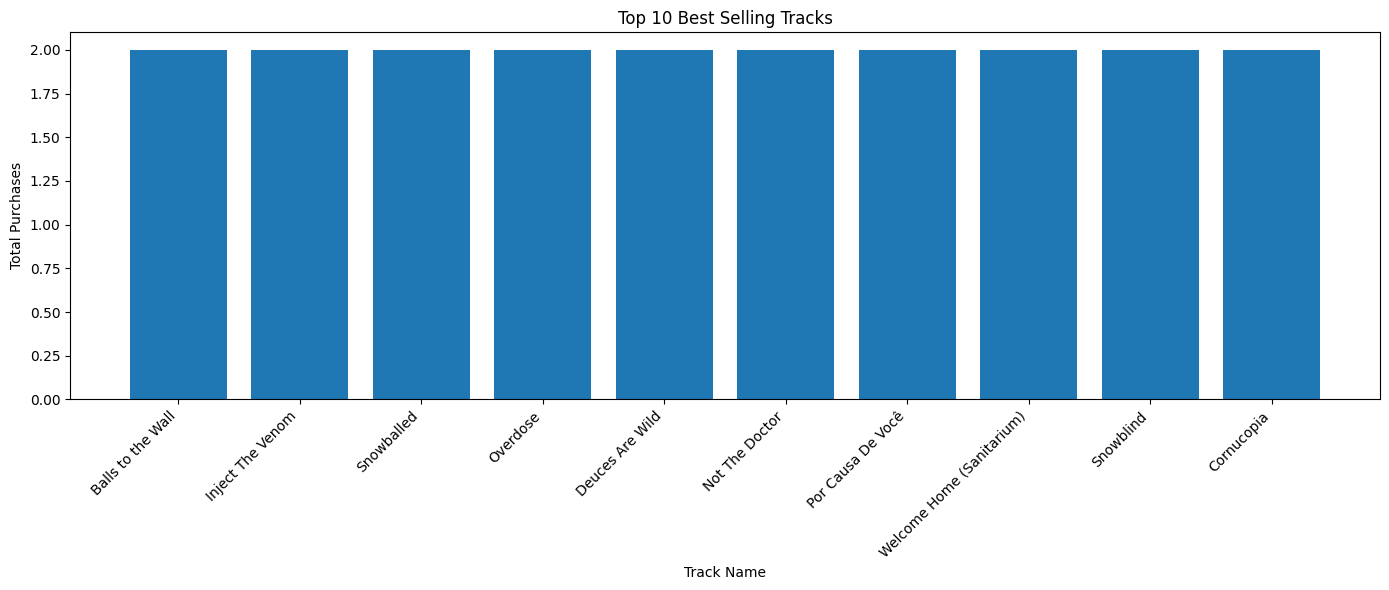

In [20]:
import matplotlib.pyplot as plt

# Create chart canvas
plt.figure(figsize=(14, 6))

# Create vertical bar chart
plt.bar(
    best_selling_tracks_df['track_name'],
    best_selling_tracks_df['total_purchases']
)

# Add chart title
plt.title('Top 10 Best Selling Tracks')

# Label x-axis
plt.xlabel('Track Name')

# Label y-axis
plt.ylabel('Total Purchases')

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')

# Automatically adjust spacing
plt.tight_layout()

# Save chart
plt.savefig(
    '../visualizations/top_tracks_vertical.png'
)

# Show chart
plt.show()

In [9]:
# Q2 Which country generates the most revenue?
import run_sql as rs

highest_revenue_country = rs.run_sql("../queries/solutions_to_queries/Country_Most_Revenue.sql", conn)

print(highest_revenue_country)

Running query from ../queries/solutions_to_queries/Country_Most_Revenue.sql:
SELECT
    BillingCountry AS country,
    SUM(Total) AS total_revenue
FROM
    Invoice
GROUP BY
    country
ORDER BY
    total_revenue DESC
LIMIT
    1;

  country  total_revenue
0     USA         523.06


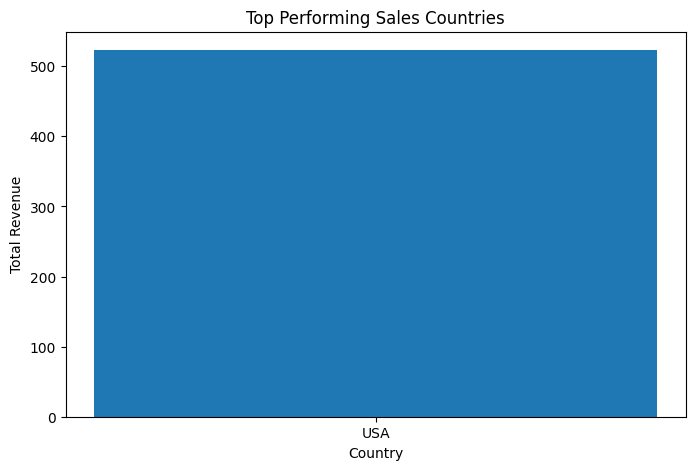

In [21]:
import matplotlib.pyplot as plt

# Create chart size
plt.figure(figsize=(8, 5))

# Create bar chart
plt.bar(
    highest_revenue_country['country'],
    highest_revenue_country['total_revenue']
)

# Add chart title
plt.title('Top Performing Sales Countries')

# Label x-axis
plt.xlabel('Country')

# Label y-axis
plt.ylabel('Total Revenue')

# Save chart
plt.savefig(
    '../visualizations/top_sales_countries.png'
)

# Show chart
plt.show()

In [13]:
# Q3: Who is the top-performing sales employee?

import run_sql as rs

top_sales_employee = rs.run_sql("../queries/solutions_to_queries/Top_Performing_Employee.sql", conn)

print(top_sales_employee)

Running query from ../queries/solutions_to_queries/Top_Performing_Employee.sql:
SELECT
    e.FirstName AS Employee_First_Name,
    e.LastName AS Employee_Last_Name,
    SUM(i.Total) AS TotalSales
FROM
    Employee e
JOIN
    Customer c
ON
    e.EmployeeId = c.SupportRepId
JOIN
    Invoice i
ON
    i.CustomerId = c.CustomerId
GROUP BY
    e.FirstName, 
    e.LastName
ORDER BY
    TotalSales DESC
LIMIT
    1;

  Employee_First_Name Employee_Last_Name  TotalSales
0                Jane            Peacock      833.04


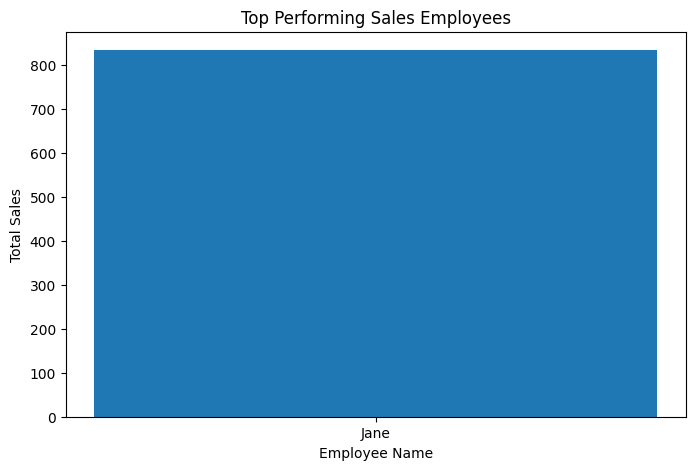

In [14]:
import matplotlib.pyplot as plt

# Create chart size
plt.figure(figsize=(8, 5))

# Create bar chart
plt.bar(
    top_sales_employee['Employee_First_Name'],
    top_sales_employee['TotalSales']
)

# Add chart title
plt.title('Top Performing Sales Employees')

# Label x-axis
plt.xlabel('Employee Name')

# Label y-axis
plt.ylabel('Total Sales')

# Save chart
plt.savefig(
    '../visualizations/top_sales_employee.png'
)

# Show chart
plt.show()